  # 00 — Schematic Drawing of a Hot Subdwarf Binary Spectrum



  This notebook creates a schematic illustration of how a cool companion can produce excess flux in the red part of a composite hot subdwarf binary spectrum.

  The figure is not based on an observed object. It is a simplified visual explanation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


  ## 1. Figure configuration



  This section defines the visual style, wavelength range, and output file names.

In [2]:
# Reproducible wavelength grid used only for the schematic curves in the figure, not for any actual data processing
WAVELENGTH_MIN = 330
WAVELENGTH_MAX = 1050
N_WAVELENGTH_POINTS = 600

# Output files are saved in both SVG and PNG formats
OUT_DIR = Path.cwd() / "results" / "00_spectra_visual"
OUTPUT_SVG = "00_sdb_rp_excess_schematic.svg"
OUTPUT_PNG = "00_sdb_rp_excess_schematic.png"

# Figure colors
VU_BURGUNDY = "#78003F"
VU_BLUE = "#6193CD"
VU_YELLOW = "#F7AA4E"
MIF_BLUE = "#00477F"
COMPANION_LABEL = "#C98527"

# Approximate Gaia XP BP/RP regions used as background guides
BP_MIN = 330
BP_MAX = 680
RP_MIN = 640
RP_MAX = 1050

# Wavelength at which the red excess is highlighted
EXCESS_MARK_WAVELENGTH = 920


  ## 2. Create schematic spectra



  Three curves are created:



  - a hot subdwarf spectrum, decreasing toward longer wavelengths;

  - a cooler companion spectrum, increasing toward the red wavelengths;

  - a composite spectrum, created as their sum.



  The curves are intentionally simplified and normalized for visual clarity.

In [3]:
wl = np.linspace(WAVELENGTH_MIN, WAVELENGTH_MAX, N_WAVELENGTH_POINTS)

# Hot subdwarf component: high blue flux, lower red flux
sdb = 1.15 * np.exp(-(wl - WAVELENGTH_MIN) / 420) + 0.08

# Cool companion component: weak in blue, stronger in red wavelengths
companion = 0.12 + 0.95 / (1 + np.exp(-(wl - 760) / 80))

# Composite spectrum: hot subdwarf plus scaled cool companion contribution
combined = sdb + 0.55 * companion

# Normalize all curves by the maximum of the composite spectrum
normalization_factor = combined.max()
sdb = sdb / normalization_factor
companion = 0.55 * companion / normalization_factor
combined = combined / normalization_factor


  ## 3. Plot schematic spectrum



  The BP/RP background shading is added only as a visual guide. The dashed vertical segment marks the approximate red-flux excess between the hot subdwarf-only curve and the composite spectrum.

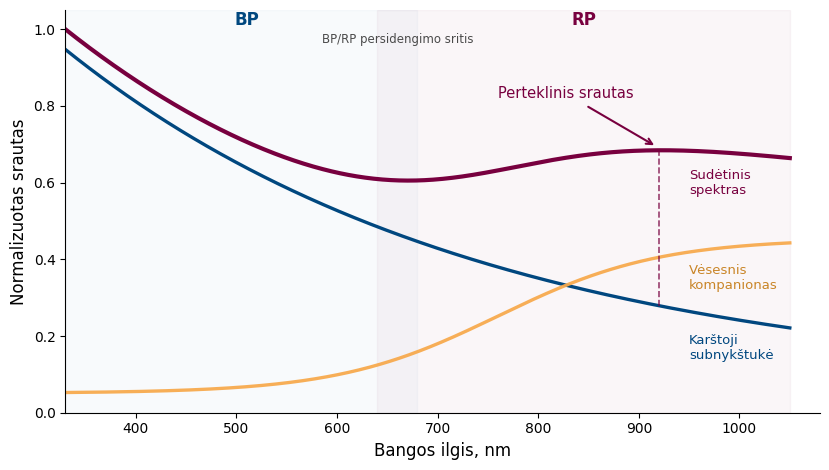

In [ ]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))

# Add approximate BP and RP wavelength-region backgrounds
ax.axvspan(BP_MIN, BP_MAX, color=VU_BLUE, alpha=0.045)
ax.axvspan(RP_MIN, RP_MAX, color=VU_BURGUNDY, alpha=0.035)

# Plot the three schematic spectral components
ax.plot(
    wl,
    sdb,
    color=MIF_BLUE,
    linewidth=2.4,
)

ax.plot(
    wl,
    companion,
    color=VU_YELLOW,
    linewidth=2.4,
    alpha=0.95,
)

ax.plot(
    wl,
    combined,
    color=VU_BURGUNDY,
    linewidth=3.0,
)

# Add minimal BP/RP labels above the corresponding wavelength regions
ax.text(
    510,
    1.01,
    "BP",
    color=MIF_BLUE,
    fontsize=12,
    fontweight="bold",
    ha="center",
)

ax.text(
    845,
    1.01,
    "RP",
    color=VU_BURGUNDY,
    fontsize=12,
    fontweight="bold",
    ha="center",
)

ax.text(
    660,
    0.965,
    "BP/RP persidengimo sritis",
    color="#4A4A4A",
    fontsize=8.5,
    ha="center",
)

# Find the y-values used to mark the excess flux at the selected wavelength
mark_index = np.argmin(np.abs(wl - EXCESS_MARK_WAVELENGTH))
y_combined = combined[mark_index]
y_sdb = sdb[mark_index]

# Highlight the vertical difference between the subdwarf-only and composite
# spectrum. This is the schematic red excess caused by the cool companion
ax.vlines(
    EXCESS_MARK_WAVELENGTH,
    y_sdb,
    y_combined,
    color=VU_BURGUNDY,
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
)

ax.annotate(
    "Perteklinis srautas",
    xy=(EXCESS_MARK_WAVELENGTH, 0.69),
    xytext=(760, 0.82),
    fontsize=10.5,
    color=VU_BURGUNDY,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5,
        color=VU_BURGUNDY,
        shrinkA=4,
        shrinkB=4,
    ),
)

# Add direct curve labels instead of a separate legend
ax.text(
    950,
    0.60,
    "Sudėtinis\nspektras",
    color=VU_BURGUNDY,
    fontsize=9.5,
    ha="left",
    va="center",
)

ax.text(
    950,
    0.35,
    "Vėsesnis\nkompanionas",
    color=COMPANION_LABEL,
    fontsize=9.5,
    ha="left",
    va="center",
)

ax.text(
    950,
    0.17,
    "Karštoji\nsubnykštukė",
    color=MIF_BLUE,
    fontsize=9.5,
    ha="left",
    va="center",
)

# Set axis labels and limits. The x-axis is extended slightly to the right
# so that inline labels do not overlap the plotted curves
ax.set_xlabel("Bangos ilgis, nm", fontsize=12)
ax.set_ylabel("Normalizuotas srautas", fontsize=12)
ax.set_xlim(330, 1080)
ax.set_ylim(0, 1.05)

# Apply clean formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

# Save the figure immediately after creating the plot
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    OUT_DIR / OUTPUT_SVG,
    format="svg",
    bbox_inches="tight",
)

plt.savefig(
    OUT_DIR / OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()